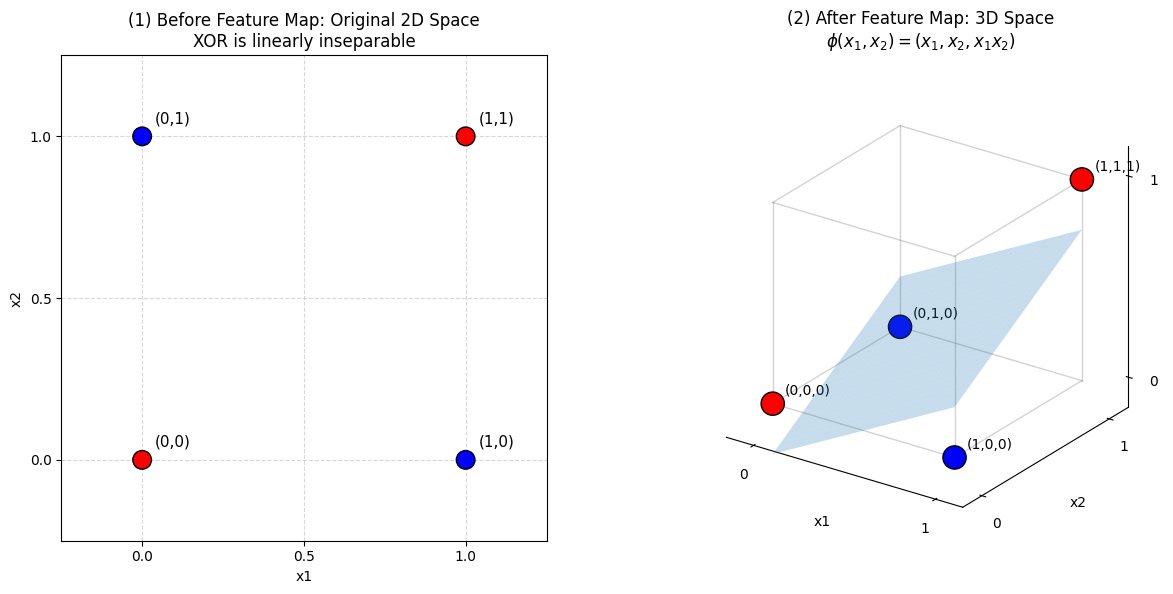

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# XOR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Class labels: 0 = red, 1 = blue
y = np.array([0, 1, 1, 0])
colors = ["red" if label == 0 else "blue" for label in y]

# Feature map: phi(x1, x2) = (x1, x2, x1*x2)
Z = np.column_stack((X[:, 0], X[:, 1], X[:, 0] * X[:, 1]))

fig = plt.figure(figsize=(13, 6))

# -------------------------
# (1) Before feature map: 2D plot
# -------------------------
ax1 = fig.add_subplot(1, 2, 1)

ax1.scatter(X[:, 0], X[:, 1], c=colors, s=180, edgecolors="black", zorder=3)

for x1, x2 in X:
    ax1.text(x1 + 0.04, x2 + 0.04, f"({x1},{x2})", fontsize=11)

ax1.set_title("(1) Before Feature Map: Original 2D Space\nXOR is linearly inseparable")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")

ax1.set_xlim(-0.25, 1.25)
ax1.set_ylim(-0.25, 1.25)

ax1.set_xticks([0, 0.5, 1])
ax1.set_yticks([0, 0.5, 1])

ax1.set_aspect("equal", adjustable="box")
ax1.grid(True, linestyle="--", alpha=0.5)


# -------------------------
# (2) After feature map: 3D plot
# -------------------------
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.set_proj_type("ortho")

# Cube corners
corners = np.array(
    [
        [0, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [1, 1, 0],
        [0, 0, 1],
        [1, 0, 1],
        [0, 1, 1],
        [1, 1, 1],
    ]
)

# Cube edges
edges = [
    (0, 1),
    (0, 2),
    (1, 3),
    (2, 3),
    (4, 5),
    (4, 6),
    (5, 7),
    (6, 7),
    (0, 4),
    (1, 5),
    (2, 6),
    (3, 7),
]

# Draw cube edges
for i, j in edges:
    ax2.plot(
        [corners[i, 0], corners[j, 0]],
        [corners[i, 1], corners[j, 1]],
        [corners[i, 2], corners[j, 2]],
        color="gray",
        alpha=0.35,
        linewidth=1,
    )

# -------------------------
# Separating plane
# -------------------------
# Plane equation:
# x1 + x2 - 2z = 0.5
# => z = 0.5 * (x1 + x2) - 0.25
xx, yy = np.meshgrid(np.linspace(0, 1, 30), np.linspace(0, 1, 30))

zz = 0.5 * (xx + yy) - 0.25

ax2.plot_surface(xx, yy, zz, alpha=0.25, shade=False)

# Draw points after the plane
ax2.scatter(
    Z[:, 0], Z[:, 1], Z[:, 2], c=colors, s=280, edgecolors="black", depthshade=False
)

# Labels
for x1, x2, z in Z:
    ax2.text(x1 + 0.04, x2 + 0.04, z + 0.04, f"({x1},{x2},{z})", fontsize=10)

ax2.set_title("(2) After Feature Map: 3D Space\n$\\phi(x_1,x_2)=(x_1,x_2,x_1x_2)$")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("z = x1*x2")

ax2.set_xlim(-0.15, 1.15)
ax2.set_ylim(-0.15, 1.15)
ax2.set_zlim(-0.15, 1.15)

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_zticks([0, 1])

ax2.set_box_aspect([1, 1, 1])
ax2.view_init(elev=25, azim=-55)

# Cleaner background panes
ax2.xaxis.pane.set_alpha(0.0)
ax2.yaxis.pane.set_alpha(0.0)
ax2.zaxis.pane.set_alpha(0.0)

ax2.grid(False)

plt.tight_layout()
plt.show()